In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'data\Life Expectancy Data.csv')
pd.set_option('display.float_format', '{:.2f}'.format)
df.columns = df.columns.str.strip()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df.shape)
df.head(16)

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.00,263.00,62,0.01,71.28,65.00,1154,19.10,83,6.00,8.16,65.00,0.10,584.26,33736494.00,17.20,17.30,0.48,10.10
1,Afghanistan,2014,Developing,59.90,271.00,64,0.01,73.52,62.00,492,18.60,86,58.00,8.18,62.00,0.10,612.70,327582.00,17.50,17.50,0.48,10.00
2,Afghanistan,2013,Developing,59.90,268.00,66,0.01,73.22,64.00,430,18.10,89,62.00,8.13,64.00,0.10,631.74,31731688.00,17.70,17.70,0.47,9.90
3,Afghanistan,2012,Developing,59.50,272.00,69,0.01,78.18,67.00,2787,17.60,93,67.00,8.52,67.00,0.10,669.96,3696958.00,17.90,18.00,0.46,9.80
4,Afghanistan,2011,Developing,59.20,275.00,71,0.01,7.10,68.00,3013,17.20,97,68.00,7.87,68.00,0.10,63.54,2978599.00,18.20,18.20,0.45,9.50
5,Afghanistan,2010,Developing,58.80,279.00,74,0.01,79.68,66.00,1989,16.70,102,66.00,9.20,66.00,0.10,553.33,2883167.00,18.40,18.40,0.45,9.20
6,Afghanistan,2009,Developing,58.60,281.00,77,0.01,56.76,63.00,2861,16.20,106,63.00,9.42,63.00,0.10,445.89,284331.00,18.60,18.70,0.43,8.90
7,Afghanistan,2008,Developing,58.10,287.00,80,0.03,25.87,64.00,1599,15.70,110,64.00,8.33,64.00,0.10,373.36,2729431.00,18.80,18.90,0.43,8.70
8,Afghanistan,2007,Developing,57.50,295.00,82,0.02,10.91,63.00,1141,15.20,113,63.00,6.73,63.00,0.10,369.84,26616792.00,19.00,19.10,0.41,8.40
9,Afghanistan,2006,Developing,57.30,295.00,84,0.03,17.17,64.00,1990,14.70,116,58.00,7.43,58.00,0.10,272.56,2589345.00,19.20,19.30,0.41,8.10


columns:

*target:*  
Life expectancy

*death stats, per 1000:*  
1. Adult Mortality - probability of dying between 15 ages and 60 
2. infant deaths - probability of newborn death  
3. under-five deaths - probability of dying under 5 ages  
4. HIV/AIDS - deaths due HIV

*vaccinations, in %, per 1000:*  
1. Hepatitis B, %
2. Polio, %  
3. Diphtheria, %  
4. Measles, per 1000

*Economy:*  
1. GDP, $, per capita
2. Total expenditure - GDP % spent on health  
3. percentage expenditure - GDP % spent on health, per capita
4. Income composition of resources, index from 0 to 1

*Society:*  
1. Schooling, years avg spent on education  
2. Alcohol, liters per capita  
3. BMI
4. thinness  1-19 years  
5. thinness 5-9 years  

*Demography:*  
1. Population  
2. Year  
3. Status, category  
4. Country  

In [2]:
from scipy.stats import skew
rows = []
for col in df.select_dtypes(include='number').columns:
    s = df[col]
    rows.append({
    'column': col,
    'min': s.min(),
    'max': s.max(),
    'std': s.std(),
    'mean': s.mean(),
    'median': s.median(),
    'skewness': skew(s, nan_policy='omit'),
    'na_count': s.isna().sum(),
    'null_pct': round(s.isna().mean() * 100, 2),
})

result = pd.DataFrame(rows).set_index('column')
print(result)

                                    min           max         std        mean  \
column                                                                          
Year                            2000.00       2015.00        4.61     2007.52   
Life expectancy                   36.30         89.00        9.52       69.22   
Adult Mortality                    1.00        723.00      124.29      164.80   
infant deaths                      0.00       1800.00      117.93       30.30   
Alcohol                            0.01         17.87        4.05        4.60   
percentage expenditure             0.00      19479.91     1987.91      738.25   
Hepatitis B                        1.00         99.00       25.07       80.94   
Measles                            0.00     212183.00    11467.27     2419.59   
BMI                                1.00         87.30       20.04       38.32   
under-five deaths                  0.00       2500.00      160.45       42.04   
Polio                       

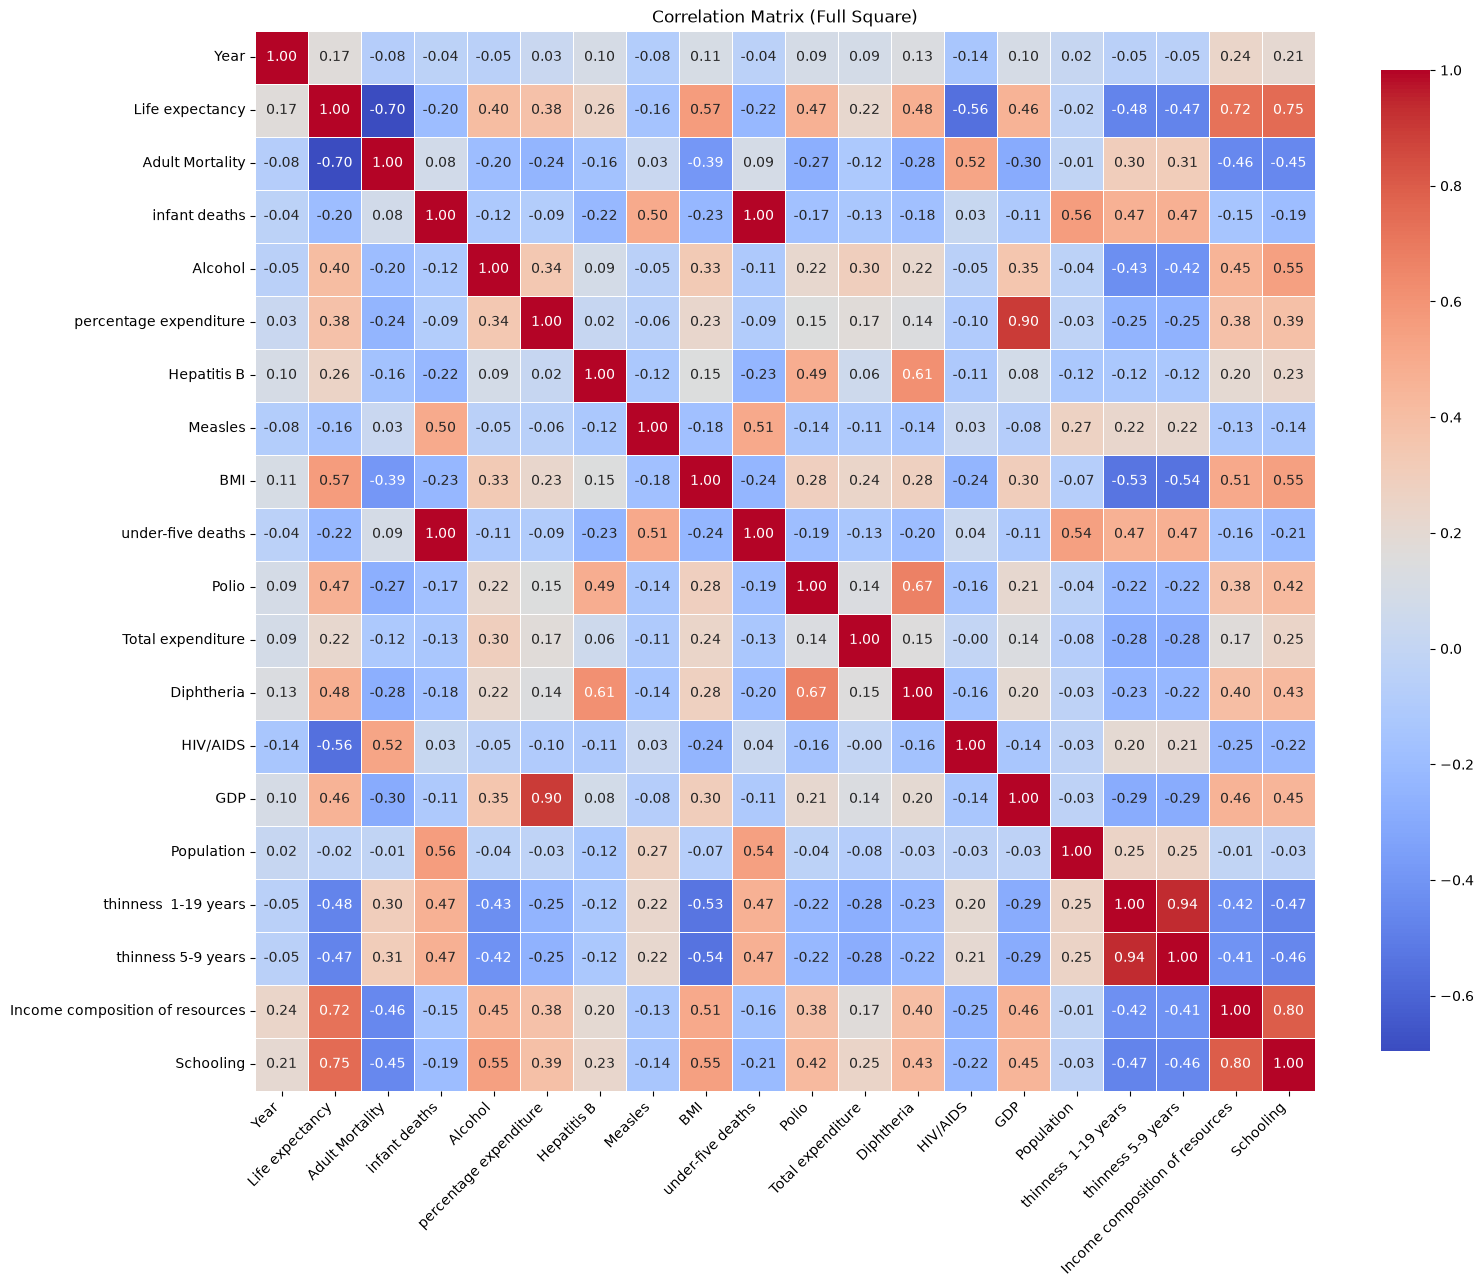

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['number'])
corr = num_cols.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix (Full Square)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'corr_value']

strong_corr = corr_pairs[corr_pairs['corr_value'].abs() > 0.7]
strong_corr = strong_corr.sort_values(
    'corr_value',
    key=abs,
    ascending=False
).reset_index(drop=True)

print(strong_corr)

                         feature_1                        feature_2  \
0                    infant deaths                under-five deaths   
1             thinness  1-19 years               thinness 5-9 years   
2           percentage expenditure                              GDP   
3  Income composition of resources                        Schooling   
4                  Life expectancy                        Schooling   
5                  Life expectancy  Income composition of resources   

   corr_value  
0        1.00  
1        0.94  
2        0.90  
3        0.80  
4        0.75  
5        0.72  


In [5]:
target = 'Life expectancy'

to_drop = ['percentage expenditure', 'under-five deaths',
           'thinness 5-9 years', 'Schooling']

df = df.drop(columns=to_drop)
df = df.dropna(subset=[target]).reset_index(drop=True)

train_df = df[df['Year'] <= 2013].copy()
val_df = df[df['Year'] == 2014].copy()
test_df = df[df['Year'] == 2015].copy()

features = [col for col in df.columns if col not in ['Year', target]]
cat_f = ['Status']
num_f = [col for col in features if col not in cat_f + ['Country']]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (2562, 16), Val: (183, 16), Test: (183, 16)


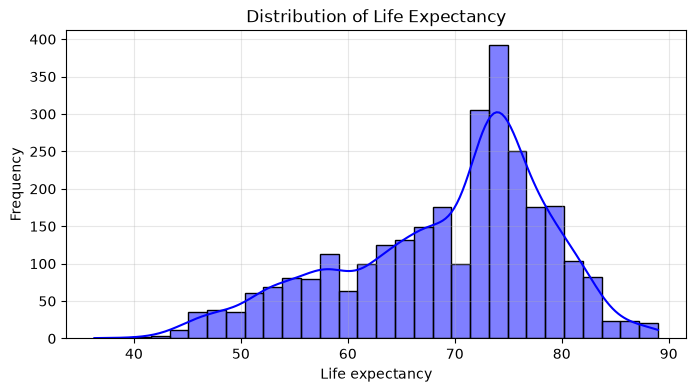

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=30, kde=True, color='blue')
plt.title('Distribution of Life Expectancy')
plt.xlabel(target)
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

class CountryStatusImputer(BaseEstimator, TransformerMixin):

    def __init__(self, country_col='Country', status_col='Status'):
        self.country_col = country_col
        self.status_col = status_col

    def fit(self, X, y=None):
        self.num_cols_ = list(
            X.drop(columns=[self.country_col, self.status_col])
             .select_dtypes(include='number').columns
        )
        self.country_mean_ = X.groupby(self.country_col)[self.num_cols_].mean()

        country_status = (
            X[[self.country_col, self.status_col]]
            .drop_duplicates()
            .set_index(self.country_col)[self.status_col]
        )
        self.status_median_ = self.country_mean_.groupby(country_status).median()
        self.global_median_ = X[self.num_cols_].median()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.num_cols_:
            X[col] = (
                X[col]
                .fillna(X[self.country_col].map(self.country_mean_[col]))
                .fillna(X[self.status_col].map(self.status_median_[col]))
                .fillna(self.global_median_[col])
            )
        return X.drop(columns=[self.country_col])

In [8]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def get_preprocessor_linear():
    return Pipeline(steps=[
        ('imputer', CountryStatusImputer()),
        ('prep', ColumnTransformer(transformers=[
            ('num', StandardScaler(), num_f),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_f),
        ])),
    ])


def get_preprocessor_tree():
    return Pipeline(steps=[
        ('imputer', CountryStatusImputer()),
        ('prep', ColumnTransformer(transformers=[
            ('num', 'passthrough', num_f),
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                                   unknown_value=-1), cat_f),
        ])),
    ])
    

def evaluate_regression(model, X, y, model_name='Model'):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, preds)
    eps = 1e-8
    mape = np.mean(np.abs((y - preds) / np.maximum(np.abs(y), eps))) * 100
    return {
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
    }
    

In [9]:
from sklearn.dummy import DummyRegressor

dummy_pipeline = Pipeline(steps=[
    ('preprocessor', get_preprocessor_tree()),
    ('dummy', DummyRegressor(strategy='mean')),
])
dummy_pipeline.fit(X_train, y_train)

results_df = pd.DataFrame([
    evaluate_regression(dummy_pipeline, X_train, y_train, 'Dummy_Train'),
    evaluate_regression(dummy_pipeline, X_val, y_val, 'Dummy_Val'),
])
print(results_df)

         Model  MAE   MSE  RMSE    R2  MAPE
0  Dummy_Train 7.90 92.83  9.63  0.00 12.43
1    Dummy_Val 7.58 79.90  8.94 -0.10 10.70


In [10]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_linear_pipeline(alpha):
    return Pipeline(steps=[
        ('country_imputer', CountryStatusImputer()),
        ('prep', ColumnTransformer(transformers=[
            ('num', StandardScaler(), num_f),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_f),
        ])),
        ('model', Ridge(alpha=alpha)),
    ])


def objective_linear(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e3, log=True)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(make_linear_pipeline(alpha), X_train, y_train,
                                cv=kf, scoring='neg_mean_absolute_error')
    return -cv_scores.mean()


study_linear = optuna.create_study(direction='minimize')
study_linear.optimize(objective_linear, n_trials=30)
print('best alpha:', study_linear.best_params['alpha'])

linear_pipeline = make_linear_pipeline(study_linear.best_params['alpha'])
linear_pipeline.fit(X_train, y_train)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_regression(linear_pipeline, X_train, y_train, 'Linear_Train'),
        evaluate_regression(linear_pipeline, X_val, y_val, 'Linear_Val')
    ])
], ignore_index=True)

print(results_df)

best alpha: 0.001004455673129834
          Model  MAE   MSE  RMSE    R2  MAPE
0   Dummy_Train 7.90 92.83  9.63  0.00 12.43
1     Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2  Linear_Train 3.27 19.26  4.39  0.79  5.05
3    Linear_Val 3.02 16.27  4.03  0.78  4.30


In [11]:
import optuna
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_et(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 16),
        'min_samples_split': trial.suggest_int('min_samples_split', 4, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 8),
        'max_features': trial.suggest_float('max_features', 0.3, 0.9),
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_maes = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train)):
        pipe = Pipeline(steps=[
            ('preprocessor', get_preprocessor_tree()),
            ('model', ExtraTreesRegressor(random_state=42, n_jobs=-1, **params)),
        ])
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        fold_maes.append(
            mean_absolute_error(y_train.iloc[va_idx],
                                pipe.predict(X_train.iloc[va_idx])))
        trial.report(np.mean(fold_maes), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_maes)


study_et = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)
study_et.optimize(objective_et, n_trials=50)
print('best params:', study_et.best_params)

et_pipe = Pipeline(steps=[
    ('preprocessor', get_preprocessor_tree()),
    ('model', ExtraTreesRegressor(random_state=42, n_jobs=-1,
                                  **study_et.best_params)),
])
et_pipe.fit(X_train, y_train)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_regression(et_pipe, X_train, y_train, 'ExtraTrees_Train_optimized'),
        evaluate_regression(et_pipe, X_val, y_val, 'ExtraTrees_Val_optimized'),
    ]),
], ignore_index=True)
print(results_df)

best params: {'n_estimators': 736, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.8671246018761675}
                        Model  MAE   MSE  RMSE    R2  MAPE
0                 Dummy_Train 7.90 92.83  9.63  0.00 12.43
1                   Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2                Linear_Train 3.27 19.26  4.39  0.79  5.05
3                  Linear_Val 3.02 16.27  4.03  0.78  4.30
4  ExtraTrees_Train_optimized 0.41  0.51  0.71  0.99  0.61
5    ExtraTrees_Val_optimized 1.19  3.70  1.92  0.95  1.67


In [16]:
from sklearn.tree import DecisionTreeRegressor


def dt_objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'criterion': trial.suggest_categorical('criterion',
                                               ['squared_error', 'absolute_error']),
    }
    fold_maes = []
    for fold, (tr_idx, va_idx) in enumerate(KF.split(X_train)):
        pre = get_preprocessor_tree()
        X_tr = pre.fit_transform(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        X_va = pre.transform(X_train.iloc[va_idx])
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = DecisionTreeRegressor(random_state=42, **params)
        model.fit(X_tr, y_tr)
        fold_maes.append(mean_absolute_error(y_va, model.predict(X_va)))
        trial.report(np.mean(fold_maes), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_maes)


study_dt = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
study_dt.optimize(dt_objective, n_trials=30)
print('best params:', study_dt.best_params)

dt_pipe = Pipeline(steps=[
    ('pre', get_preprocessor_tree()),
    ('model', DecisionTreeRegressor(random_state=42, **study_dt.best_params)),
])
dt_pipe.fit(X_train, y_train)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_regression(dt_pipe, X_train, y_train, 'DT_Train'),
        evaluate_regression(dt_pipe, X_val, y_val, 'DT_Val'),
    ]),
], ignore_index=True)
print(results_df)

best params: {'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 0.517401637803699, 'criterion': 'absolute_error'}
                         Model  MAE   MSE  RMSE    R2  MAPE
0                  Dummy_Train 7.90 92.83  9.63  0.00 12.43
1                    Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2                 Linear_Train 3.27 19.26  4.39  0.79  5.05
3                   Linear_Val 3.02 16.27  4.03  0.78  4.30
4   ExtraTrees_Train_optimized 0.41  0.51  0.71  0.99  0.61
5     ExtraTrees_Val_optimized 1.19  3.70  1.92  0.95  1.67
6                    XGB_Train 0.28  0.19  0.43  1.00  0.41
7                      XGB_Val 1.28  3.98  1.99  0.95  1.83
8                   LGBM_Train 0.43  0.45  0.67  1.00  0.63
9                     LGBM_Val 1.26  3.74  1.93  0.95  1.77
10                    DT_Train 0.28  0.29  0.54  1.00  0.42
11                      DT_Val 1.95  8.83  2.97  0.88  2.80
12                    DT_Train 1.40  5.66  2.38  0.94  2.15
13             

These parameters caused model overfitting:  
params = {  
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),  
        'max_depth': trial.suggest_int('max_depth', 3, 30),  
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),  
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),  
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),  
    }  
best params: {'n_estimators': 379, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.9835648443812535}    

ExtraTrees_Train 0.07  0.02  0.15  1.00  0.11  
ExtraTrees_Val 1.08  3.16  1.78  0.96  1.52



In [12]:
import xgboost as xgb
from sklearn.model_selection import KFold

optuna.logging.set_verbosity(optuna.logging.WARNING)
KF = KFold(n_splits=5, shuffle=True, random_state=42)


def xgb_objective(trial):
    params = dict(
        learning_rate=trial.suggest_float('learning_rate', 3e-2, 2e-1, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 6),
        min_child_weight=trial.suggest_int('min_child_weight', 3, 10),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.7, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 1e1, log=True),
    )
    fold_maes, fold_iters = [], []
    for fold, (tr_idx, va_idx) in enumerate(KF.split(X_train)):
        pre = get_preprocessor_tree()
        X_tr = pre.fit_transform(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        X_va = pre.transform(X_train.iloc[va_idx])
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = xgb.XGBRegressor(n_estimators=600, early_stopping_rounds=50,
                                 n_jobs=-1, random_state=42, **params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        fold_iters.append(model.best_iteration)
        fold_maes.append(mean_absolute_error(y_va, model.predict(X_va)))
        trial.report(np.mean(fold_maes), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr('n_iter', int(np.mean(fold_iters)))
    return np.mean(fold_maes)


study_xgb = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
study_xgb.optimize(xgb_objective, n_trials=30)
print('XGB best params:', study_xgb.best_params)

xgb_pipe = Pipeline(steps=[
    ('pre', get_preprocessor_tree()),
    ('model', xgb.XGBRegressor(
        n_estimators=study_xgb.best_trial.user_attrs['n_iter'],
        n_jobs=-1, random_state=42, **study_xgb.best_params)),
])
xgb_pipe.fit(X_train, y_train)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_regression(xgb_pipe, X_train, y_train, 'XGB_Train'),
        evaluate_regression(xgb_pipe, X_val, y_val, 'XGB_Val'),
    ]),
], ignore_index=True)
print(results_df)

XGB best params: {'learning_rate': 0.05907349911748457, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8791005984052249, 'colsample_bytree': 0.9994480049021593, 'reg_lambda': 2.8136120451008066}
                        Model  MAE   MSE  RMSE    R2  MAPE
0                 Dummy_Train 7.90 92.83  9.63  0.00 12.43
1                   Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2                Linear_Train 3.27 19.26  4.39  0.79  5.05
3                  Linear_Val 3.02 16.27  4.03  0.78  4.30
4  ExtraTrees_Train_optimized 0.41  0.51  0.71  0.99  0.61
5    ExtraTrees_Val_optimized 1.19  3.70  1.92  0.95  1.67
6                   XGB_Train 0.28  0.19  0.43  1.00  0.41
7                     XGB_Val 1.28  3.98  1.99  0.95  1.83


In [14]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 3e-1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1e1, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1e1, log=True),
        'subsample_freq': 1,
    }
    fold_maes, fold_iters = [], []
    for fold, (tr_idx, va_idx) in enumerate(KF.split(X_train)):
        pre = get_preprocessor_tree()
        X_tr = pre.fit_transform(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        X_va = pre.transform(X_train.iloc[va_idx])
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMRegressor(n_estimators=600, n_jobs=-1,
                                  random_state=42, verbose=-1, **params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        fold_iters.append(model.best_iteration_)
        fold_maes.append(mean_absolute_error(y_va, model.predict(X_va)))
        trial.report(np.mean(fold_maes), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr('n_iter', int(np.mean(fold_iters)))
    return np.mean(fold_maes)


study_lgb = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
study_lgb.optimize(lgb_objective, n_trials=30)
print('LGBM best params:', study_lgb.best_params)

lgb_params = dict(study_lgb.best_params)
lgb_params['subsample_freq'] = 1
lgb_pipe = Pipeline(steps=[
    ('pre', get_preprocessor_tree()),
    ('model', lgb.LGBMRegressor(
        n_estimators=study_lgb.best_trial.user_attrs['n_iter'],
        n_jobs=-1, random_state=42, verbose=-1, **lgb_params)),
])
lgb_pipe.fit(X_train, y_train)

results_df = pd.concat([
    results_df,
    pd.DataFrame([
        evaluate_regression(lgb_pipe, X_train, y_train, 'LGBM_Train'),
        evaluate_regression(lgb_pipe, X_val, y_val, 'LGBM_Val'),
    ]),
], ignore_index=True)
print(results_df)

c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated,

LGBM best params: {'learning_rate': 0.029386218566079637, 'num_leaves': 36, 'max_depth': 8, 'min_child_samples': 13, 'subsample': 0.8738386516538424, 'colsample_bytree': 0.8246276619985375, 'reg_lambda': 0.44296916056228064, 'reg_alpha': 0.003549704758482857}
                        Model  MAE   MSE  RMSE    R2  MAPE
0                 Dummy_Train 7.90 92.83  9.63  0.00 12.43
1                   Dummy_Val 7.58 79.90  8.94 -0.10 10.70
2                Linear_Train 3.27 19.26  4.39  0.79  5.05
3                  Linear_Val 3.02 16.27  4.03  0.78  4.30
4  ExtraTrees_Train_optimized 0.41  0.51  0.71  0.99  0.61
5    ExtraTrees_Val_optimized 1.19  3.70  1.92  0.95  1.67
6                   XGB_Train 0.28  0.19  0.43  1.00  0.41
7                     XGB_Val 1.28  3.98  1.99  0.95  1.83
8                  LGBM_Train 0.43  0.45  0.67  1.00  0.63
9                    LGBM_Val 1.26  3.74  1.93  0.95  1.77
